In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMRegressor, LGBMClassifier
import sys
import re
from sklearn.preprocessing import LabelEncoder
import plotly.express as px
from scipy.stats import spearmanr

In [131]:
df_listings = pd.read_csv("../data/Listing/listed_transactions.csv")
df_listings.head()

C:\Users\mayab\AppData\Local\Temp\ipykernel_19408\3410094314.py:1: DtypeWarning: Columns (0: ListAgentEmail, 1: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  df_listings = pd.read_csv("../data/Listing/listed_transactions.csv")


,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,Year
0,90000.0,1075010398,miriamlara03@gmail.com,NaN,NaN,Miriam,Lara,34.097939,-117.909653,1045 N Azusa 61,...,NaN,2.0,Covina Valley Unified,91722,NaN,0.0,NaN,NaN,1045 N Azusa 61,2024
1,1500000.0,1074974457,janelle@judsonre.com,NaN,NaN,Janelle,Judson,33.121241,-117.081614,NaN,...,NaN,NaN,NaN,92025,NaN,0.0,NaN,NaN,NaN,2024
2,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,False,NaN,NaN,90067,NaN,2105.0,177861.0,NaN,2220 Avenue Of The Stars 2704,2024
3,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,False,3.0,Capistrano Unified,92677,NaN,254.0,5300.0,NaN,16 Palisades,2024
4,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road,2024


##### Number of Rows and Columns

In [132]:
df_listings.shape

(892774, 85)

The listing transactions file has 853754 rows and 87 columns. 

##### Review column data types

In [133]:
df_listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 892774 entries, 0 to 892773
Data columns (total 85 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             889335 non-null  float64
 1   ListingKey                    892774 non-null  int64  
 2   ListAgentEmail                819336 non-null  str    
 3   CloseDate                     260134 non-null  str    
 4   ClosePrice                    235942 non-null  float64
 5   ListAgentFirstName            887511 non-null  str    
 6   ListAgentLastName             892697 non-null  str    
 7   Latitude                      780321 non-null  float64
 8   Longitude                     781047 non-null  float64
 9   UnparsedAddress               890413 non-null  str    
 10  PropertyType                  892774 non-null  str    
 11  LivingArea                    782032 non-null  float64
 12  ListPrice                     890556 non-null  float64


In [134]:
df_listings.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1',
       'ListingId', 'BathroomsTotalInteger', 'Cit

In [135]:
df_listings.isna().sum()

OriginalListPrice                 3439
ListingKey                           0
ListAgentEmail                   73438
CloseDate                       632640
ClosePrice                      656832
                                 ...  
AssociationFee                  288402
LotSizeSquareFeet                82123
MiddleOrJuniorSchoolDistrict    892774
UnparsedAddress.1                 2361
Year                                 0
Length: 85, dtype: int64

#### **Missing Value Analysis**

##### Calculate missing counts and percentages per column

In [136]:
missing_listing_counts = df_listings.isnull().sum()
missing_listing_counts

OriginalListPrice                 3439
ListingKey                           0
ListAgentEmail                   73438
CloseDate                       632640
ClosePrice                      656832
                                 ...  
AssociationFee                  288402
LotSizeSquareFeet                82123
MiddleOrJuniorSchoolDistrict    892774
UnparsedAddress.1                 2361
Year                                 0
Length: 85, dtype: int64

In [137]:
missing_listing_percent = (df_listings.isnull().mean()) * 100
missing_listing_percent

OriginalListPrice                 0.385204
ListingKey                        0.000000
ListAgentEmail                    8.225822
CloseDate                        70.862279
ClosePrice                       73.572035
                                   ...    
AssociationFee                   32.304032
LotSizeSquareFeet                 9.198633
MiddleOrJuniorSchoolDistrict    100.000000
UnparsedAddress.1                 0.264457
Year                              0.000000
Length: 85, dtype: float64

In [138]:
missing_summary = pd.DataFrame({
    "missing_listing_counts": missing_listing_counts,
    "missing_listing_percent": missing_listing_percent
})

In [139]:
missing_listing_summary = missing_summary.sort_values(by="missing_listing_percent", ascending=False)
print(missing_listing_summary)

                              missing_listing_counts  missing_listing_percent
MiddleOrJuniorSchoolDistrict                  892774                    100.0
ElementarySchoolDistrict                      892774                    100.0
CoveredSpaces                                 892774                    100.0
AboveGradeFinishedArea                        892774                    100.0
FireplacesTotal                               892774                    100.0
...                                              ...                      ...
PropertyType.1                                     0                      0.0
ListingKeyNumeric                                  0                      0.0
DaysOnMarket.1                                     0                      0.0
ListingContractDate                                0                      0.0
Year                                               0                      0.0

[85 rows x 2 columns]


In [140]:
missing_listing_summary = missing_listing_summary[missing_listing_summary["missing_listing_counts"] > 0]
print(missing_listing_summary)

                              missing_listing_counts  missing_listing_percent
MiddleOrJuniorSchoolDistrict                  892774               100.000000
ElementarySchoolDistrict                      892774               100.000000
CoveredSpaces                                 892774               100.000000
AboveGradeFinishedArea                        892774               100.000000
FireplacesTotal                               892774               100.000000
...                                              ...                      ...
PostalCode                                       218                 0.024418
ListAgentLastName                                 77                 0.008625
ListAgentLastName.1                               77                 0.008625
StateOrProvince                                   71                 0.007953
CountyOrParish                                     1                 0.000112

[74 rows x 2 columns]


In [141]:
missing_listing_summary["missing_listing_percent"] = missing_listing_summary["missing_listing_percent"].round(2)
print(missing_listing_summary)

                              missing_listing_counts  missing_listing_percent
MiddleOrJuniorSchoolDistrict                  892774                   100.00
ElementarySchoolDistrict                      892774                   100.00
CoveredSpaces                                 892774                   100.00
AboveGradeFinishedArea                        892774                   100.00
FireplacesTotal                               892774                   100.00
...                                              ...                      ...
PostalCode                                       218                     0.02
ListAgentLastName                                 77                     0.01
ListAgentLastName.1                               77                     0.01
StateOrProvince                                   71                     0.01
CountyOrParish                                     1                     0.00

[74 rows x 2 columns]


In [142]:
missing_above_90 = missing_listing_summary[missing_listing_summary['missing_listing_percent'] > 90]
print(missing_above_90)

                              missing_listing_counts  missing_listing_percent
MiddleOrJuniorSchoolDistrict                  892774                   100.00
ElementarySchoolDistrict                      892774                   100.00
CoveredSpaces                                 892774                   100.00
AboveGradeFinishedArea                        892774                   100.00
FireplacesTotal                               892774                   100.00
TaxYear                                       891875                    99.90
BelowGradeFinishedArea                        889157                    99.59
BusinessType                                  886542                    99.30
TaxAnnualAmount                               886427                    99.29
CoBuyerAgentFirstName                         872768                    97.76
BuilderName                                   862241                    96.58
LotSizeDimensions                             841763            

In [143]:
missing_above_70 = missing_listing_summary[missing_listing_summary['missing_listing_percent'] > 70]
print(missing_above_70)

                              missing_listing_counts  missing_listing_percent
MiddleOrJuniorSchoolDistrict                  892774                   100.00
ElementarySchoolDistrict                      892774                   100.00
CoveredSpaces                                 892774                   100.00
AboveGradeFinishedArea                        892774                   100.00
FireplacesTotal                               892774                   100.00
TaxYear                                       891875                    99.90
BelowGradeFinishedArea                        889157                    99.59
BusinessType                                  886542                    99.30
TaxAnnualAmount                               886427                    99.29
CoBuyerAgentFirstName                         872768                    97.76
BuilderName                                   862241                    96.58
LotSizeDimensions                             841763            

In [144]:
missing_above_70.shape

(31, 2)

In [145]:
missing_above_70

,missing_listing_counts,missing_listing_percent
MiddleOrJuniorSchoolDistrict,892774,100.00
ElementarySchoolDistrict,892774,100.00
CoveredSpaces,892774,100.00
AboveGradeFinishedArea,892774,100.00
FireplacesTotal,892774,100.00
TaxYear,891875,99.90
BelowGradeFinishedArea,889157,99.59
BusinessType,886542,99.30
TaxAnnualAmount,886427,99.29
CoBuyerAgentFirstName,872768,97.76


To perserve the variables, it would be sufficient if each variable contain less than 70% of missing values in order to use imputation to replace the missingness in the data. 

So, variables with 70% of missing variables will be removed from the dataset because through imputation with variables with a significant number of missingness, it may contribute to bias towards certain values than others. 

Keep these key variables (from above 70):
- ClosePrice
- CloseDate

In [146]:
df_listings_clean = df_listings.drop(columns=['MiddleOrJuniorSchoolDistrict', 'ElementarySchoolDistrict', 'CoveredSpaces',
                                             'AboveGradeFinishedArea', 'FireplacesTotal', 'TaxYear', 
                                             'BelowGradeFinishedArea', 'BusinessType', 'TaxAnnualAmount',
                                             'CoBuyerAgentFirstName', 'BuilderName', 'LotSizeDimensions',
                                             'ElementarySchool', 'MiddleOrJuniorSchool', 'HighSchool',
                                             'BuyerAgencyCompensation', 'BuyerAgencyCompensationType', 'BuildingAreaTotal',
                                             'CoListAgentFirstName', 'CoListAgentLastName', 'CoListOfficeName', 'BuyerOfficeAOR',
                                            'BuyerOfficeName.1', 'AssociationFeeFrequency', 'BuyerAgentFirstName',
                                             'BuyerAgentMlsId', 'BuyerAgentLastName', 'CloseDate.1'])

Dropping Variables:
- MiddleOrJuniorSchoolDistrict                  
- ElementarySchoolDistrict
- CoveredSpaces
- AboveGradeFinishedArea
- FireplacesTotal
- TaxYear
- BelowGradeFinishedArea
- BusinessType
- TaxAnnualAmount
- CoBuyerAgentFirstName
- BuilderName
- LotSizeDimensions
- ElementarySchool
- MiddleOrJuniorSchool

In [147]:
# Calculate percentage for all columns
missing_pct = (df_listings_clean.isna().sum() / len(df_listings_clean)) * 100

# Filter to show only columns that actually have missing data
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

ClosePrice                  73.572035
BuyerOfficeName             72.073335
CloseDate                   70.862279
SubdivisionName             66.621900
PurchaseContractDate        57.570673
MainLevelBedrooms           53.776768
HighSchoolDistrict          39.701649
AttachedGarageYN            34.031233
AssociationFee              32.304032
Stories                     25.928510
Levels                      19.212589
GarageSpaces                18.906353
FireplaceYN                 14.282674
NewConstructionYN           13.384238
Latitude                    12.595909
Latitude.1                  12.595909
Longitude.1                 12.514589
Longitude                   12.514589
LivingArea                  12.404259
LivingArea.1                12.404259
PropertySubType             12.132074
BedroomsTotal               12.007742
MLSAreaMajor                11.326047
LotSizeAcres                 9.514166
LotSizeSquareFeet            9.198633
LotSizeArea                  9.074525
ListAgentEma

In [148]:
num_cols_with_missing = df_listings_clean.isna().any().sum()

print(f"Number of variables with missing values: {num_cols_with_missing}")

Number of variables with missing values: 46


In [149]:
cols_rows_dropping = missing_pct[(missing_pct < 1) & (missing_pct > 0)]
cols_rows_dropping

OriginalListPrice           0.385204
ListAgentFirstName          0.589511
ListAgentLastName           0.008625
UnparsedAddress             0.264457
ListPrice                   0.248439
ListAgentFullName           0.028003
CountyOrParish              0.000112
ListAgentFirstName.1        0.589511
StreetNumberNumeric         0.451514
City                        0.109434
ContractStatusChangeDate    0.825069
ListPrice.1                 0.248439
StateOrProvince             0.007953
ListAgentLastName.1         0.008625
PostalCode                  0.024418
UnparsedAddress.1           0.264457
dtype: float64

In [150]:
cols_rows_dropped = ['OriginalListPrice', 'ListAgentFirstName', 'ListAgentLastName', 'UnparsedAddress', 'ListPrice', 'ListAgentFullName', 'CountyOrParish',
        'StreetNumberNumeric', 'City', 'ContractStatusChangeDate','StateOrProvince', 'PostalCode']

In [151]:
df_listings_clean = df_listings_clean.dropna(subset=['OriginalListPrice', 'ListAgentFirstName', 'ListAgentLastName', 'UnparsedAddress', 'ListPrice', 'ListAgentFullName', 'CountyOrParish',
        'StreetNumberNumeric', 'City', 'ContractStatusChangeDate','StateOrProvince', 'PostalCode'])

In [152]:
df_listings_clean.shape

(871642, 57)

In [153]:
# Create a reference mapping of Names -> Emails
# Drop any rows that have missing emails so the map is 'clean'
email_lookup = df_listings_clean.dropna(subset=['ListAgentEmail']).drop_duplicates(['ListAgentFirstName', 'ListAgentLastName'])

# Set the names as the index to make the 'lookup' possible
email_lookup = email_lookup.set_index(['ListAgentFirstName', 'ListAgentLastName'])['ListAgentEmail']

# Create a function to apply the logic
def fill_missing_emails(row):
    # Only try to fill if the current email is missing
    if pd.isna(row['ListAgentEmail']):
        # Look up the name in our reference map
        return email_lookup.get((row['ListAgentFirstName'], row['ListAgentLastName']), "None")
    return row['ListAgentEmail']

# Apply it to the dataframe
df_listings_clean['ListAgentEmail'] = df_listings_clean.apply(fill_missing_emails, axis=1)

In [154]:
df_listings_clean['ListAgentEmail'].isna().sum()

np.int64(0)

In [155]:
(df_listings_clean['ListAgentEmail'] == 'None').sum()

np.int64(2857)

From the code above, I noticed that there are no missing values for list agent's first and last names, so to determine their emails, I tried to look up any matches by full name to get the list agent's emails for the rows that are missing them. If there are no matches, those emails will be preserved by having a value of "None" (i.e. no email provided).

In [156]:
df_listings_clean.isna().sum()

OriginalListPrice                0
ListingKey                       0
ListAgentEmail                   0
CloseDate                   616377
ClosePrice                  639081
ListAgentFirstName               0
ListAgentLastName                0
Latitude                    108864
Longitude                   108165
UnparsedAddress                  0
PropertyType                     0
LivingArea                  105011
ListPrice                        0
DaysOnMarket                     0
ListOfficeName                   0
BuyerOfficeName             625568
ListAgentFullName                0
ListingKeyNumeric                0
MLSAreaMajor                 98462
CountyOrParish                   0
PropertyType.1                   0
MlsStatus                        0
ListAgentFirstName.1             0
AttachedGarageYN            295408
ParkingTotal                 51673
PropertySubType             104627
LotSizeAcres                 82729
SubdivisionName             580451
YearBuilt           

In [157]:
df_listings_clean.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'ListAgentFullName', 'ListingKeyNumeric', 'MLSAreaMajor',
       'CountyOrParish', 'PropertyType.1', 'MlsStatus', 'ListAgentFirstName.1',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'YearBuilt', 'DaysOnMarket.1', 'StreetNumberNumeric',
       'LivingArea.1', 'ListingId', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'Longitude.1',
       'PurchaseContractDate', 'ListingContractDate', 'Latitude.1',
       'ListPrice.1', 'StateOrProvince', 'FireplaceYN', 'Stories', 'Levels',
       'ListAgentLastName.1', 'LotSizeArea', 'MainLevelBedrooms',
       'NewConstructionYN', 'GarageSpaces', 'HighSchoolDist

#### **Convert date fields to datetime format (CloseDate, PurchaseContractDate, ListingContractDate, ContractStatusChangeDate)**

In [158]:
df_listings_clean['CloseDate'] = pd.to_datetime(df_listings_clean['CloseDate'], errors='coerce')

In [159]:
df_listings_clean['PurchaseContractDate'] = pd.to_datetime(df_listings_clean['PurchaseContractDate'], errors='coerce')

In [160]:
df_listings_clean['ListingContractDate'] = pd.to_datetime(df_listings_clean['ListingContractDate'], errors='coerce')

In [161]:
df_listings_clean['ContractStatusChangeDate'] = pd.to_datetime(df_listings_clean['ContractStatusChangeDate'], errors='coerce')

In [162]:
print(df_listings_clean['PurchaseContractDate'].dtype)

datetime64[us]


#### **Remove unnecessary or redundant columns**

In [163]:
df_listings_clean.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'ListAgentFullName', 'ListingKeyNumeric', 'MLSAreaMajor',
       'CountyOrParish', 'PropertyType.1', 'MlsStatus', 'ListAgentFirstName.1',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'YearBuilt', 'DaysOnMarket.1', 'StreetNumberNumeric',
       'LivingArea.1', 'ListingId', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'Longitude.1',
       'PurchaseContractDate', 'ListingContractDate', 'Latitude.1',
       'ListPrice.1', 'StateOrProvince', 'FireplaceYN', 'Stories', 'Levels',
       'ListAgentLastName.1', 'LotSizeArea', 'MainLevelBedrooms',
       'NewConstructionYN', 'GarageSpaces', 'HighSchoolDist

In [164]:
df_listings_clean.shape

(871642, 57)

In [165]:
df_listings_clean = df_listings_clean.drop(columns=['PropertyType.1', 'ListAgentFirstName.1', 'DaysOnMarket.1', 'LivingArea.1', 'Longitude.1', 
                                                        'Latitude.1', 'ListPrice.1', 'ListAgentLastName.1', 'UnparsedAddress.1'])

In [166]:
df_listings_clean.shape

(871642, 48)

In [167]:
(df_listings_clean['OriginalListPrice'] == df_listings_clean['ListPrice']).value_counts()

True     703837
False    167805
Name: count, dtype: int64

#### **Outlier Cleaning**

Remove or flag invalid numeric values: ClosePrice <=0, LivingArea <=0, DaysOnMarket < 0, negative Bedrooms or Bathrooms

Removing and inspecting negative values

In [168]:
neg_counts = (df_listings_clean.select_dtypes(include='number') < 0).sum()

In [169]:
neg_counts[neg_counts > 0]

Latitude             7
Longitude       763254
DaysOnMarket        37
ParkingTotal       173
dtype: int64

In [170]:
(neg_counts[neg_counts > 0] / df_listings_clean.shape[0] * 100).sort_values(ascending=False)

Longitude       87.565078
ParkingTotal     0.019848
DaysOnMarket     0.004245
Latitude         0.000803
dtype: float64

ParkingTotal        

In [171]:
neg_ParkingTotal = df_listings_clean[df_listings_clean['ParkingTotal'] < 0]
neg_ParkingTotal.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,Levels,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,Year
8443,2300000.0,1058688466,mabroukhamza093@gmail.com,NaT,NaN,Hamza,Mabrouk,NaN,NaN,725 Hyde Street,...,NaN,1650.0,NaN,NaN,NaN,San Francisco Unified,94109,0.0,1650.0,2024
12223,1258000.0,1058416008,trisha@trishamotter.com,2024-02-15,1600000.0,Trisha,Motter,NaN,NaN,7385 Forsum Road,...,NaN,5227.0,NaN,False,2.0,Other,95138,NaN,5227.0,2024
26306,1588888.0,1054056032,maryoproperties@yahoo.com,2024-02-23,1550000.0,Mary,O'neill,NaN,NaN,2965 Calle De Las Estrella,...,NaN,3920.0,NaN,False,2.0,Other,95148,120.0,3920.0,2024
30751,1599000.0,1061806243,kroyer.re@gmail.com,2024-04-02,1620000.0,Kathy,Royer,NaN,NaN,6088 Pietz Court,...,NaN,6098.0,NaN,False,2.0,San Jose Unified,95123,NaN,6098.0,2024
31804,1400000.0,1061770369,rick.talmage@compass.com,2024-03-27,1550000.0,Rick,Talmage,NaN,NaN,994 La Mesa Terrace E,...,NaN,NaN,NaN,False,2.0,Other,94086,655.0,NaN,2024


In [172]:
neg_ParkingTotal.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,Levels,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,Year
8443,2300000.0,1058688466,mabroukhamza093@gmail.com,NaT,NaN,Hamza,Mabrouk,NaN,NaN,725 Hyde Street,...,NaN,1650.0,NaN,NaN,NaN,San Francisco Unified,94109,0.0,1650.0,2024
12223,1258000.0,1058416008,trisha@trishamotter.com,2024-02-15,1600000.0,Trisha,Motter,NaN,NaN,7385 Forsum Road,...,NaN,5227.0,NaN,False,2.0,Other,95138,NaN,5227.0,2024
26306,1588888.0,1054056032,maryoproperties@yahoo.com,2024-02-23,1550000.0,Mary,O'neill,NaN,NaN,2965 Calle De Las Estrella,...,NaN,3920.0,NaN,False,2.0,Other,95148,120.0,3920.0,2024
30751,1599000.0,1061806243,kroyer.re@gmail.com,2024-04-02,1620000.0,Kathy,Royer,NaN,NaN,6088 Pietz Court,...,NaN,6098.0,NaN,False,2.0,San Jose Unified,95123,NaN,6098.0,2024
31804,1400000.0,1061770369,rick.talmage@compass.com,2024-03-27,1550000.0,Rick,Talmage,NaN,NaN,994 La Mesa Terrace E,...,NaN,NaN,NaN,False,2.0,Other,94086,655.0,NaN,2024


In [173]:
df_listings_clean['ParkingTotal'].describe()

count    8.199690e+05
mean     6.342753e+00
std      2.873782e+03
min     -1.430000e+02
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      2.593669e+06
Name: ParkingTotal, dtype: float64

DaysOnMarket              

In [174]:
neg_DaysOnMarket = df_listings_clean[df_listings_clean['DaysOnMarket'] < 0]
neg_DaysOnMarket.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,Levels,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,Year
223,799000.0,1063549350,ainsleyhughes@kw.com,2024-03-21,799000.0,Ainsley,Hughes,34.425577,-119.291855,11905 Silver Spur Street,...,One,5885.0,NaN,NaN,2.0,NaN,93023,59.0,5885.0,2024
228,899000.0,1063528331,absea@comcast.net,2024-03-19,810000.0,A.B.,Priceman DRE 0126...,39.383806,-123.789254,31530 Emerald Drive,...,One,0.8,NaN,False,2.0,NaN,95437,NaN,34848.0,2024
752,11500.0,1061271257,teresa.fuller@compass.com,2024-03-07,10500.0,Teresa,Fuller,34.081125,-118.363403,536 N Edinburgh Avenue,...,One,6612.0,5.0,NaN,0.0,NaN,90048,0.0,6612.0,2024
1119,1599000.0,1060153479,robert@anppros.com,2024-03-21,1625000.0,Robert,Perez,34.244449,-118.265167,3929 El Moreno Street,...,Two,5249.0,NaN,NaN,2.0,NaN,91214,NaN,5249.0,2024
4167,469999.0,1059512539,khoren9@yahoo.com,NaT,NaN,Khoren,Barutyan,34.201700,-118.460053,15015 Sherman Way 103,...,"One,Two",15574.0,0.0,False,2.0,Los Angeles Unified,91405,390.0,15574.0,2024


In [175]:
rows_DaysOnMarket = neg_DaysOnMarket['DaysOnMarket']
rows_DaysOnMarket.head()

223    -48
228    -58
752    -16
1119    -1
4167   -33
Name: DaysOnMarket, dtype: int64

In [176]:
non_neg = (df_listings_clean['DaysOnMarket'] >= 0) & (df_listings_clean['ParkingTotal'] >= 0)

In [177]:
df_listings_clean = df_listings_clean[non_neg].copy()

In [178]:
df_listings_clean.shape

(819760, 48)

In [179]:
neg_counts = (df_listings_clean.select_dtypes(include='number') < 0).sum()

In [180]:
neg_counts[neg_counts > 0]

Latitude          4
Longitude    716097
dtype: int64

In [181]:
df_listings_clean['missing_coordinates_flag'] = df_listings_clean['Latitude'].isna() | df_listings_clean['Longitude'].isna()

In [182]:
df_listings_clean['missing_coordinates_flag'].value_counts()

missing_coordinates_flag
False    715565
True     104195
Name: count, dtype: int64

In [183]:
df_listings_clean['sentinel_null_flag'] = (df_listings_clean['Latitude'] == 0) | (df_listings_clean['Longitude'] == 0)

In [184]:
df_listings_clean['sentinel_null_flag'].value_counts()

sentinel_null_flag
False    819675
True         85
Name: count, dtype: int64

In [185]:
df_listings_clean['positive_longitude_flag'] = df_listings_clean['Longitude'] > 0

In [186]:
df_listings_clean['positive_longitude_flag'].value_counts()

positive_longitude_flag
False    819675
True         85
Name: count, dtype: int64

In [187]:
df_listings_clean['out_of_state_flag'] = (
    ~(
        (df_listings_clean['Latitude'] >= 32.5) &
        (df_listings_clean['Latitude'] <= 42.0) &
        (df_listings_clean['Longitude'] >= -124.5) &
        (df_listings_clean['Longitude'] <= -114.1)
    )
    & ~df_listings_clean['missing_coordinates_flag']
    & ~df_listings_clean['sentinel_null_flag']
)

In [188]:
df_listings_clean['out_of_state_flag'].value_counts()

out_of_state_flag
False    819495
True        265
Name: count, dtype: int64

In [189]:
df_listings_clean.shape

(819760, 52)

In [190]:
'''
df_map = df_listings_clean.sample(30000)

fig = px.scatter_mapbox(
    df_map,
    lat="Latitude",
    lon="Longitude",
    color="OriginalListPrice",
    size_max=15,
    zoom=5,
    title="California Property Value Distribution",
    color_continuous_scale=px.colors.sequential.Plasma,
    mapbox_style="open-street-map"
)

fig.show(renderer='browser')
'''

'\ndf_map = df_listings_clean.sample(30000)\n\nfig = px.scatter_mapbox(\n    df_map,\n    lat="Latitude",\n    lon="Longitude",\n    color="OriginalListPrice",\n    size_max=15,\n    zoom=5,\n    title="California Property Value Distribution",\n    color_continuous_scale=px.colors.sequential.Plasma,\n    mapbox_style="open-street-map"\n)\n\nfig.show(renderer=\'browser\')\n'

In [191]:
df_listings_clean.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'ListAgentFullName', 'ListingKeyNumeric', 'MLSAreaMajor',
       'CountyOrParish', 'MlsStatus', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'YearBuilt',
       'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN',
       'GarageSpaces', 'HighSchoolDistrict', 'PostalCode', 'AssociationFee',
       'LotSizeSquareFeet', 'Year', 'missing_coordinates_flag',
       'sentinel_null_flag', 'positive_longitude_flag'

In [192]:
listings_cleaned_df = pd.read_csv("../data/Listing/listings_cleaned_df.csv")
listings_cleaned_df.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,listing_after_close_flag,purchase_after_close_flag,negative_timeline_flag,price_ratio,price_per_sqft,Month,YrMo,CloseToOriginalListRatio,ListingToContractDays,ContractToCloseDays
0,90000.0,1075010398,miriamlara03@gmail.com,NaN,NaN,Miriam,Lara,34.097939,-117.909653,1045 N Azusa 61,...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,False,False,False,NaN,NaN,NaN,NaN,NaN,127 days,NaN
2,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [193]:
listings_cleaned_df.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'ListAgentFullName', 'ListingKeyNumeric', 'MLSAreaMajor',
       'CountyOrParish', 'MlsStatus', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'YearBuilt',
       'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN',
       'GarageSpaces', 'HighSchoolDistrict', 'PostalCode', 'AssociationFee',
       'LotSizeSquareFeet', 'Year', 'missing_coordinates_flag',
       'sentinel_null_flag', 'positive_longitude_flag'

In [194]:
numeric_cols = ['ClosePrice', 'LivingArea', 'DaysOnMarket']

for col in numeric_cols:
    Q1 = listings_cleaned_df[col].quantile(0.25)
    Q3 = listings_cleaned_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    listings_cleaned_df[f'{col}_Outlier'] = (
        (listings_cleaned_df[col] < lower) |
        (listings_cleaned_df[col] > upper)
    )

ClosePrice

In [195]:
listings_cleaned_df[listings_cleaned_df['ClosePrice_Outlier'] == True].shape

(9831, 73)

In [196]:
listings_cleaned_df[listings_cleaned_df['ClosePrice'].notna()].shape

(228274, 73)

In [197]:
listings_cleaned_df[listings_cleaned_df['ClosePrice'].notna()].shape[0] / len(listings_cleaned_df)

0.27846442861325266

In [198]:
non_missing_ClosePrice = listings_cleaned_df[listings_cleaned_df['ClosePrice'].notna()]

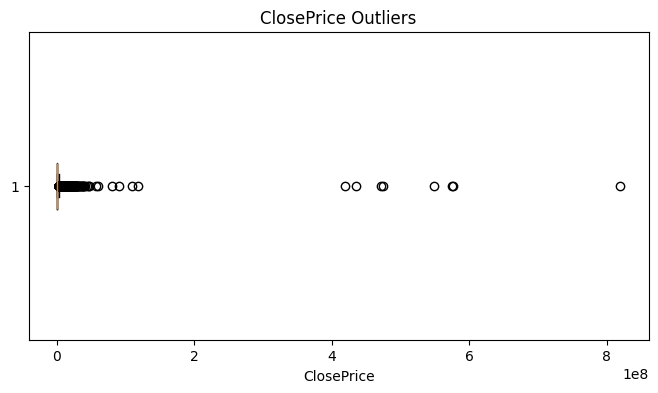

In [199]:
plt.figure(figsize=(8, 4))
plt.boxplot(non_missing_ClosePrice['ClosePrice'], vert=False)

plt.title('ClosePrice Outliers')
plt.xlabel('ClosePrice')

plt.show()

In [206]:
outliers_ClosePrice = non_missing_ClosePrice[non_missing_ClosePrice['ClosePrice_Outlier']]

In [207]:
outliers_ClosePrice['ClosePrice'].describe()

count    9.831000e+03
mean     4.745430e+06
std      1.605737e+07
min      2.543000e+06
25%      2.880000e+06
50%      3.400000e+06
75%      4.495000e+06
max      8.200000e+08
Name: ClosePrice, dtype: float64

(0.0, 50000000.0)

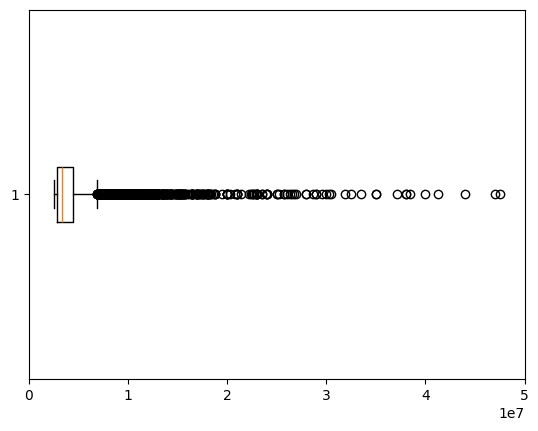

In [456]:
plt.boxplot(outliers_ClosePrice['ClosePrice'], vert=False)
plt.xlim(0, 5e7)

In [210]:
outliers_ClosePrice.nlargest(5, 'ClosePrice')

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,price_ratio,price_per_sqft,Month,YrMo,CloseToOriginalListRatio,ListingToContractDays,ContractToCloseDays,ClosePrice_Outlier,LivingArea_Outlier,DaysOnMarket_Outlier
470376,810000.0,1111840152,shirinchauvin@gmail.com,2025-05-07,820000000.0,Shirin,Chauvin,33.736291,-117.782177,2871 Player Lane,...,1012.345679,684474.123539,5.0,2025-05,1012.345679,7 days,15 days,True,False,False
270538,575000.0,1086383049,davidsilvarealtor@gmail.com,2024-10-01,576000000.0,David,Silva,33.212747,-117.278805,4524 Quailridge Drive,...,1001.739130,659793.814433,10.0,2024-10,1001.739130,7 days,15 days,True,False,False
534126,610000.0,1118301783,apyjar@bhhscal.com,2026-02-13,575000000.0,Arlene,Pyjar,32.746900,-116.932357,11422 Via Rancho San Diego 84,...,942.622951,472861.842105,2.0,2026-02,942.622951,180 days,58 days,True,False,True
660873,585000.0,1146220143,carrie@sellsandiegorealestate.com,2025-12-29,549000000.0,Carrie,Baker-Bailey,32.753434,-116.928390,12003 Calle De Leon 3,...,938.461538,482001.755926,12.0,2025-12,938.461538,23 days,25 days,True,False,False
627476,399999.0,1145138107,suzymanzano@hotmail.com,2025-12-28,475000000.0,Suzy,Manzano,32.735819,-117.093750,2872 47th Street,...,1187.502969,486680.327869,12.0,2025-12,1187.502969,36 days,23 days,True,False,False


In [ ]:
filtered_df_ClosePrice = non_missing_ClosePrice[~non_missing_ClosePrice['ClosePrice_Outlier']]

In [212]:
filtered_df_ClosePrice.shape

(218443, 73)

In [214]:
non_missing_ClosePrice['ClosePrice'].describe()

count    2.282740e+05
mean     7.782772e+05
std      3.486934e+06
min      0.000000e+00
25%      4.950000e+03
50%      5.700000e+05
75%      1.020000e+06
max      8.200000e+08
Name: ClosePrice, dtype: float64

In [213]:
filtered_df_ClosePrice['ClosePrice'].describe()

count    2.184430e+05
mean     5.997360e+05
std      6.023660e+05
min      0.000000e+00
25%      4.700000e+03
50%      5.350000e+05
75%      9.350000e+05
max      2.542000e+06
Name: ClosePrice, dtype: float64

<Axes: >

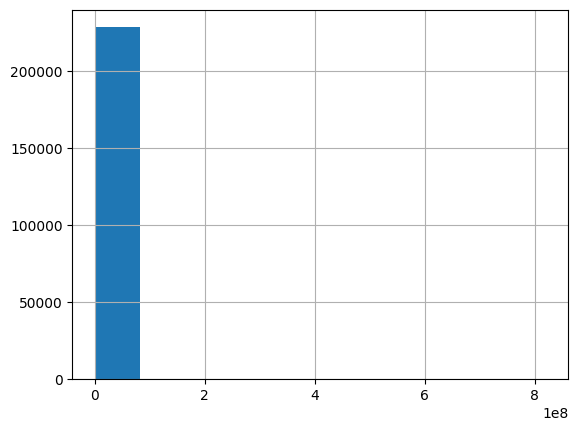

In [215]:
(non_missing_ClosePrice['ClosePrice']).hist()

<Axes: >

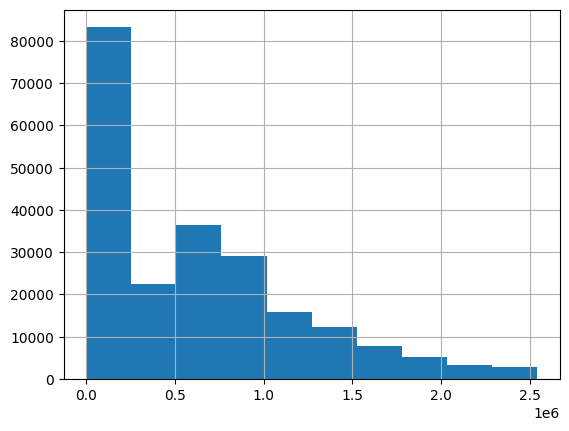

In [216]:
(filtered_df_ClosePrice['ClosePrice']).hist()

In [460]:
print(non_missing_ClosePrice['ClosePrice'].mean())
print(filtered_df_ClosePrice['ClosePrice'].mean())

778277.1914577219
599735.9656601493


Initially, the original histogram was heavily compressed due to extreme outlier values, making the histogram difficult to interpret of any trends except where the close prices are heavily clustered. After removing the outliers using the IQR method, the distribution became more visible and showed a right-skewed pattern. 

The dataset is sensitive to extreme values as the number of expensive houses are pulling the average upward. So, the original mean may not reflect what a typical home sells for. I will remove the outliers for the ClosePrice to better predict reasonable houses prices that these sellers are typically working with. 

In [218]:
listings_cleaned_df = listings_cleaned_df[~listings_cleaned_df['ClosePrice_Outlier']]

In [219]:
listings_cleaned_df.shape

(809929, 73)

Square Footage

In [220]:
listings_cleaned_df[listings_cleaned_df['LivingArea_Outlier'] == True].shape

(44835, 73)

In [221]:
listings_cleaned_df[listings_cleaned_df['LivingArea'].notna()].shape

(809929, 73)

In [222]:
listings_cleaned_df[listings_cleaned_df['LivingArea_Outlier'] == True].shape[0] / len(listings_cleaned_df)

0.05535670410616239

In [223]:
non_missing_SqFt = listings_cleaned_df[listings_cleaned_df['LivingArea'].notna()]

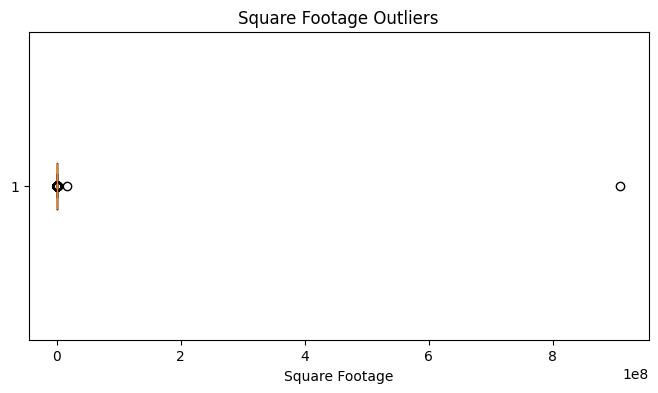

In [224]:
plt.figure(figsize=(8, 4))
plt.boxplot(non_missing_SqFt['LivingArea'], vert=False)

plt.title('Square Footage Outliers')
plt.xlabel('Square Footage')

plt.show()

In [225]:
outliers_SqFt = non_missing_SqFt[non_missing_SqFt['LivingArea_Outlier']]

In [226]:
outliers_SqFt = listings_cleaned_df[(listings_cleaned_df['LivingArea_Outlier'] == True)]
outliers_SqFt.shape

(44835, 73)

In [228]:
outliers_SqFt['LivingArea'].describe()

count    4.483500e+04
mean     2.640996e+04
std      4.294121e+06
min      3.622000e+03
25%      3.976000e+03
50%      4.513000e+03
75%      5.722000e+03
max      9.090909e+08
Name: LivingArea, dtype: float64

(0.0, 150000.0)

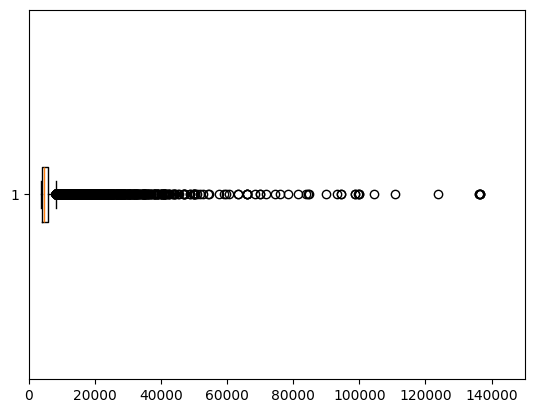

In [265]:
plt.boxplot(outliers_SqFt['LivingArea'], vert=False)
plt.xlim(0, 1.5e5)

In [243]:
outliers_SqFt.nlargest(5, 'LivingArea')

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,price_ratio,price_per_sqft,Month,YrMo,CloseToOriginalListRatio,ListingToContractDays,ContractToCloseDays,ClosePrice_Outlier,LivingArea_Outlier,DaysOnMarket_Outlier
101877,2195.0,1067203748,bartelspm@aol.com,NaN,NaN,Lynette,Bartels,37.918142,-122.315436,5647 Madison Ave,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False
448199,616000.0,1108264257,karen.smith@tripointehomes.com,NaN,NaN,Karen,Smith,32.567470,-117.013220,5360 Seacliff PL UNIT 66,...,NaN,NaN,NaN,NaN,NaN,27 days,NaN,False,True,False
100623,1750000.0,1067768023,ray@bayrealtyca.com,NaN,NaN,Ray,Sharma,NaN,NaN,1687 Jameson Canyon Rd,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False
438745,125000.0,1108572999,abigail@delcoronadorealty.com,NaN,NaN,Abigail,Baker,32.682733,-117.181047,1057 Ocean Blvd,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False
632540,125000.0,1144571712,j.r.rebeiro@gmail.com,NaN,NaN,John,Rebeiro,32.682733,-117.181047,1059 Ocean Blvd,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,True


In [248]:
filtered_df_SqFt = non_missing_SqFt[~non_missing_SqFt['LivingArea_Outlier']]

In [249]:
filtered_df_SqFt.shape

(765094, 73)

In [250]:
non_missing_SqFt['LivingArea'].describe()

count    8.099290e+05
mean     3.020955e+03
std      1.010327e+06
min      0.000000e+00
25%      1.200000e+03
50%      1.600000e+03
75%      2.148000e+03
max      9.090909e+08
Name: LivingArea, dtype: float64

In [251]:
filtered_df_SqFt['LivingArea'].describe()

count    765094.000000
mean       1650.344233
std         664.876129
min           0.000000
25%        1180.000000
50%        1600.000000
75%        2009.000000
max        3621.000000
Name: LivingArea, dtype: float64

<Axes: >

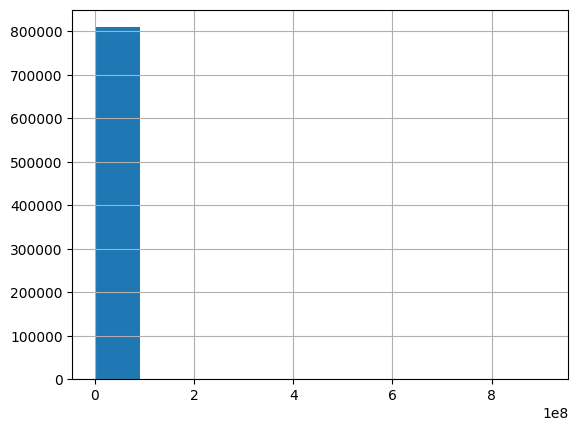

In [252]:
(non_missing_SqFt['LivingArea']).hist()

<Axes: >

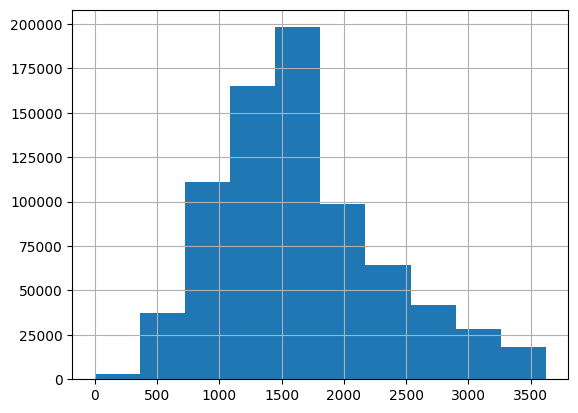

In [253]:
(filtered_df_SqFt['LivingArea']).hist()

In [271]:
non_missing_SqFt.shape[0] - filtered_df_SqFt.shape[0]

44835

In [266]:
filtered_2_SqFt = non_missing_SqFt[non_missing_SqFt['LivingArea'] < 1.5e5]
filtered_2_SqFt.shape

(809916, 73)

In [267]:
filtered_2_SqFt['LivingArea'].describe()

count    809916.000000
mean       1868.086197
std        1465.558321
min           0.000000
25%        1200.000000
50%        1600.000000
75%        2148.000000
max      136488.000000
Name: LivingArea, dtype: float64

<Axes: >

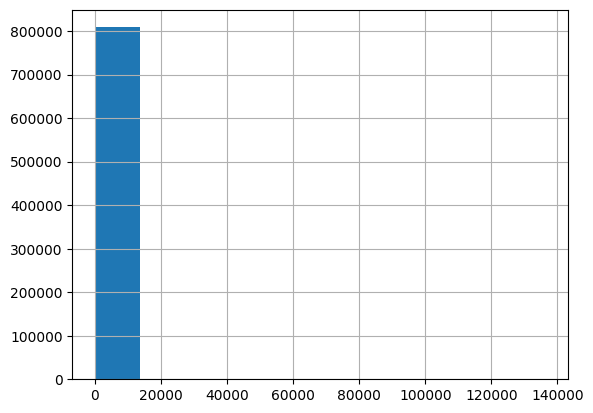

In [268]:
(filtered_2_SqFt['LivingArea']).hist()

In [273]:
non_missing_SqFt.shape[0] - filtered_2_SqFt.shape[0]

13

In [269]:
print(non_missing_SqFt['LivingArea'].mean())
print(filtered_df_SqFt['LivingArea'].mean())
print(filtered_2_SqFt['LivingArea'].mean())

3020.9552185068073
1650.3442330876992
1868.0861968031254


Though if I remove all the square footage outliers, it results in an histogram with a visible distribution of being right-skewed, I have decided to only remove the extreme outliers rather than all. There could be visible trends with those that have larger square footage (these are the outliers that are clustered or close together - so normal outliers).

In [274]:
listings_cleaned_df = listings_cleaned_df[listings_cleaned_df['LivingArea'] < 1.5e5]

In [275]:
listings_cleaned_df.shape

(809916, 73)

DaysOnMarket

In [276]:
listings_cleaned_df[listings_cleaned_df['DaysOnMarket_Outlier'] == True].shape

(70157, 73)

In [277]:
listings_cleaned_df[listings_cleaned_df['DaysOnMarket'].notna()].shape

(809916, 73)

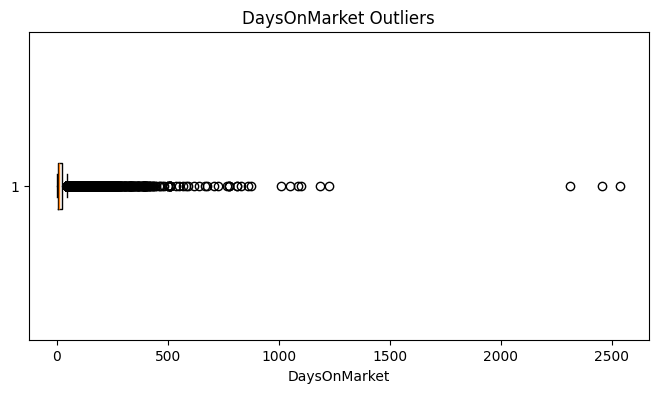

In [279]:
plt.figure(figsize=(8, 4))
plt.boxplot(listings_cleaned_df['DaysOnMarket'], vert=False)

plt.title('DaysOnMarket Outliers')
plt.xlabel('DaysOnMarket')

plt.show()

In [280]:
outliers_DaysOnMarket = listings_cleaned_df[listings_cleaned_df['DaysOnMarket_Outlier']]

In [282]:
listings_cleaned_df['DaysOnMarket'].describe()

count    809916.000000
mean         18.782761
std          27.604054
min           0.000000
25%           5.000000
50%          10.000000
75%          22.000000
max        2539.000000
Name: DaysOnMarket, dtype: float64

(0.0, 1000.0)

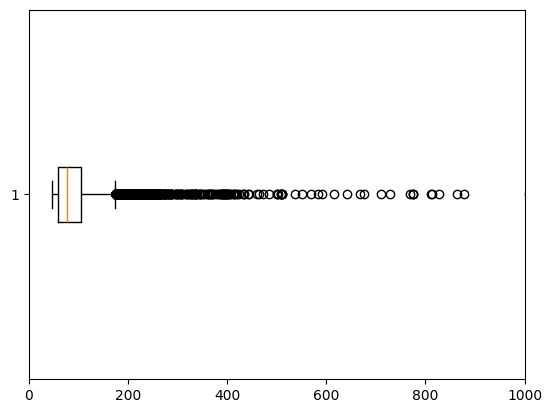

In [288]:
plt.boxplot(outliers_DaysOnMarket['DaysOnMarket'], vert=False)
plt.xlim(0, 1000)

In [289]:
outliers_DaysOnMarket.nlargest(5, 'DaysOnMarket')

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,price_ratio,price_per_sqft,Month,YrMo,CloseToOriginalListRatio,ListingToContractDays,ContractToCloseDays,ClosePrice_Outlier,LivingArea_Outlier,DaysOnMarket_Outlier
24933,1000.0,421654881,luann.hall@sbcglobal.net,NaN,NaN,Lu Ann,Hall,33.138645,-117.180289,823 Grand Avenue 203,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True
350848,3900.0,421654959,delmarre2020@gmail.com,NaN,NaN,Dick,Jacobson,32.960844,-117.266425,1558 CAMINO DEL MAR 529,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True
368068,1150000.0,1102978316,mickpfaff@gmail.com,NaN,NaN,Mick,Pfaff,36.432274,-121.771571,39 Arroyo Sequoia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True
373715,499000.0,1102755011,fvento@intero.com,NaN,NaN,Frank,Vento,NaN,NaN,0 Pescadero Road,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True
811509,99000.0,1157041585,felamistadrealestate@gmail.com,NaN,NaN,Fel,Amistad,NaN,NaN,7517202 Vacant Land (APN 075-172-02),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True


In [290]:
filtered_df_DaysOnMarket = listings_cleaned_df[~listings_cleaned_df['DaysOnMarket_Outlier']]

In [292]:
filtered_df_DaysOnMarket.shape

(739759, 73)

In [293]:
listings_cleaned_df['DaysOnMarket'].describe()

count    809916.000000
mean         18.782761
std          27.604054
min           0.000000
25%           5.000000
50%          10.000000
75%          22.000000
max        2539.000000
Name: DaysOnMarket, dtype: float64

In [294]:
filtered_df_DaysOnMarket['DaysOnMarket'].describe()

count    739759.000000
mean         12.052770
std          10.638031
min           0.000000
25%           4.000000
50%           9.000000
75%          18.000000
max          47.000000
Name: DaysOnMarket, dtype: float64

<Axes: >

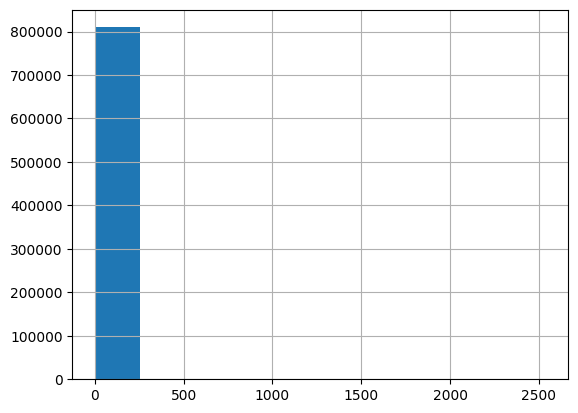

In [295]:
(listings_cleaned_df['DaysOnMarket']).hist()

<Axes: >

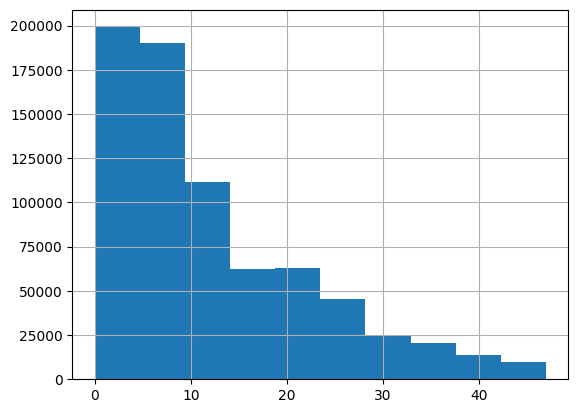

In [296]:
(filtered_df_DaysOnMarket['DaysOnMarket']).hist()

In [299]:
filtered_2_DaysOnMarket = listings_cleaned_df[listings_cleaned_df['DaysOnMarket'] < 1000]
filtered_2_DaysOnMarket.shape

(809907, 73)

In [300]:
listings_cleaned_df.shape[0] - filtered_2_DaysOnMarket.shape[0]

9

<Axes: >

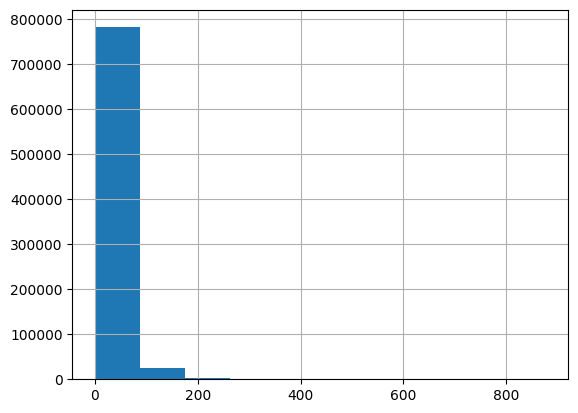

In [301]:
(filtered_2_DaysOnMarket['DaysOnMarket']).hist()

In [302]:
print(listings_cleaned_df['DaysOnMarket'].mean())
print(filtered_df_DaysOnMarket['DaysOnMarket'].mean())
print(filtered_2_DaysOnMarket['DaysOnMarket'].mean())

18.782761422172175
12.052769888571818
18.765727423025112


By removing all the outliers via the IQR method, we will be losing that representativeness. From comparing the outlier cutoff I decided, it is pretty close to the original DaysOnMarket mean, but removes only the extreme outliers. 

In [304]:
listings_cleaned_df = listings_cleaned_df[listings_cleaned_df['DaysOnMarket'] < 1000]

In [305]:
listings_cleaned_df.shape

(809907, 73)

#### **Further Handling Missing Values Appropriately**

In [306]:
df_listings_clean = listings_cleaned_df.copy()

In [307]:
missing_listing_counts = df_listings_clean.isnull().sum()
missing_listing_counts

OriginalListPrice             0
ListingKey                    0
ListAgentEmail             2724
CloseDate                568800
ClosePrice               591466
                          ...  
ListingToContractDays    453269
ContractToCloseDays      575010
ClosePrice_Outlier            0
LivingArea_Outlier            0
DaysOnMarket_Outlier          0
Length: 73, dtype: int64

In [308]:
missing_listing_percent = (df_listings_clean.isnull().mean()) * 100
missing_listing_percent

OriginalListPrice         0.000000
ListingKey                0.000000
ListAgentEmail            0.336335
CloseDate                70.230286
ClosePrice               73.028879
                           ...    
ListingToContractDays    55.965561
ContractToCloseDays      70.997040
ClosePrice_Outlier        0.000000
LivingArea_Outlier        0.000000
DaysOnMarket_Outlier      0.000000
Length: 73, dtype: float64

In [309]:
missing_summary = pd.DataFrame({
    "missing_listing_counts": missing_listing_counts,
    "missing_listing_percent": missing_listing_percent
})

In [310]:
missing_listing_summary = missing_summary.sort_values(by="missing_listing_percent", ascending=False)
print(missing_listing_summary)

                          missing_listing_counts  missing_listing_percent
ClosePrice                                591466                73.028879
price_ratio                               591466                73.028879
price_per_sqft                            591466                73.028879
CloseToOriginalListRatio                  591466                73.028879
BuyerOfficeName                           577771                71.337944
...                                          ...                      ...
listing_after_close_flag                       0                 0.000000
No_Purchase_Date                               0                 0.000000
ClosePrice_Outlier                             0                 0.000000
LivingArea_Outlier                             0                 0.000000
DaysOnMarket_Outlier                           0                 0.000000

[73 rows x 2 columns]


In [311]:
missing_listing_summary[missing_listing_summary['missing_listing_percent'] > 0]

,missing_listing_counts,missing_listing_percent
ClosePrice,591466,73.028879
price_ratio,591466,73.028879
price_per_sqft,591466,73.028879
CloseToOriginalListRatio,591466,73.028879
BuyerOfficeName,577771,71.337944
ContractToCloseDays,575010,70.997040
CloseDate,568800,70.230286
YrMo,568800,70.230286
Month,568800,70.230286
Year,568800,70.230286


In [312]:
continuous_columns = df_listings_clean.select_dtypes(include=['int64', 'float64']).columns

In [313]:
#df_listings_clean[continuous_columns].corr(method = "spearman").round(2)

In [314]:
'''corrs =df_listings_clean[continuous_columns].corr(method = "spearman")
mask = np.zeros_like(corrs)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corrs, cmap='Spectral_r', mask=mask, square=True, vmin=-.4, vmax=.4)
plt.title('Correlation matrix')'''

'corrs =df_listings_clean[continuous_columns].corr(method = "spearman")\nmask = np.zeros_like(corrs)\nmask[np.triu_indices_from(mask)] = True\nsns.heatmap(corrs, cmap=\'Spectral_r\', mask=mask, square=True, vmin=-.4, vmax=.4)\nplt.title(\'Correlation matrix\')'

In [315]:
'''pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)'''

"pd.set_option('display.max_rows', None)\npd.set_option('display.max_columns', None)\npd.set_option('display.width', None)\npd.set_option('display.max_colwidth', None)"

In [316]:
'''corr_matrix = df_listings_clean[continuous_columns].corr(method="spearman").round(2)

moderate_corr = corr_matrix.stack()
moderate_corr = moderate_corr[(moderate_corr.abs() >= 0.3) & (moderate_corr.abs() < 0.7)]

print(moderate_corr)'''

'corr_matrix = df_listings_clean[continuous_columns].corr(method="spearman").round(2)\n\nmoderate_corr = corr_matrix.stack()\nmoderate_corr = moderate_corr[(moderate_corr.abs() >= 0.3) & (moderate_corr.abs() < 0.7)]\n\nprint(moderate_corr)'

- Under 10% missing -> simple statistical imputation method, but for categorical variables, may include a "Missing" category if deemed necessary
- 10-50% missing -> "Decision Zone" - meaning that there are different approaches that can be taken to impute the missing values like a group-based imputation, model-based if justifiable, adding a missing indicator, or doing simple imputation if necessary
- above 50% -> Since at this point, they are probably important features, the missingness in the data could be important and signals themselves. 

Let's start with "Under 10% missing"

In [317]:
under_10 = missing_listing_summary[(missing_listing_summary['missing_listing_percent'] < 10) & (missing_listing_percent != 0)]

C:\Users\mayab\AppData\Local\Temp\ipykernel_19408\2293341584.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  under_10 = missing_listing_summary[(missing_listing_summary['missing_listing_percent'] < 10) & (missing_listing_percent != 0)]


In [318]:
under_10

,missing_listing_counts,missing_listing_percent
ListAgentEmail,2724,0.336335


In [319]:
df_listings_clean['MLSAreaMajor'].describe()

count      809907
unique       1143
top       Missing
freq        91568
Name: MLSAreaMajor, dtype: object

In [320]:
df_listings_clean['MLSAreaMajor'].value_counts().head()

MLSAreaMajor
Missing                               91568
699 - Not Defined                     75476
SRCAR - Southwest Riverside County    31277
252 - Riverside                        8434
C14 - Santa Monica                     5632
Name: count, dtype: int64

In [321]:
df_listings_clean['MLSAreaMajor'].value_counts(normalize=True).head()

MLSAreaMajor
Missing                               0.113060
699 - Not Defined                     0.093191
SRCAR - Southwest Riverside County    0.038618
252 - Riverside                       0.010414
C14 - Santa Monica                    0.006954
Name: proportion, dtype: float64

In [322]:
df_listings_clean['MLSAreaMajor'] = df_listings_clean['MLSAreaMajor'].fillna("Missing")

In [323]:
df_listings_clean['MLSAreaMajor'].isna().sum()

np.int64(0)

In [324]:
df_listings_clean['LotSizeAcres'].describe()

count    8.099070e+05
mean     5.173670e+02
std      4.115473e+05
min      0.000000e+00
25%      1.253000e-01
50%      1.700000e-01
75%      2.748500e-01
max      3.702600e+08
Name: LotSizeAcres, dtype: float64

In [325]:
df_listings_clean['LotSizeAcres'] = df_listings_clean['LotSizeAcres'].fillna(df_listings_clean['LotSizeAcres'].median())

In [326]:
df_listings_clean['LotSizeAcres'].isna().sum()

np.int64(0)

The mean is greater than the median. The values are skewed to the right. I will be using the median to impute. 

In [327]:
df_listings_clean['LotSizeArea'].describe()

count    8.099070e+05
mean     5.190562e+04
std      2.333012e+06
min      0.000000e+00
25%      5.126000e+03
50%      7.129000e+03
75%      1.089000e+04
max      9.187423e+08
Name: LotSizeArea, dtype: float64

In [328]:
df_listings_clean['LotSizeArea'] = df_listings_clean['LotSizeArea'].fillna(df_listings_clean['LotSizeArea'].median())

In [329]:
df_listings_clean['LotSizeArea'].isna().sum()

np.int64(0)

In [330]:
df_listings_clean['LotSizeArea'].describe()

count    8.099070e+05
mean     5.190562e+04
std      2.333012e+06
min      0.000000e+00
25%      5.126000e+03
50%      7.129000e+03
75%      1.089000e+04
max      9.187423e+08
Name: LotSizeArea, dtype: float64

In [331]:
df_listings_clean['LotSizeSquareFeet'].describe()

count    8.099070e+05
mean     4.795991e+05
std      2.137885e+07
min      0.000000e+00
25%      5.402000e+03
50%      7.380000e+03
75%      1.196000e+04
max      7.638115e+09
Name: LotSizeSquareFeet, dtype: float64

The mean is less than the median. The values are skewed to the left. I will be using the median to impute the missing values. 

In [332]:
df_listings_clean['LotSizeSquareFeet'] = df_listings_clean['LotSizeSquareFeet'].fillna(df_listings_clean['LotSizeSquareFeet'].median())

In [333]:
df_listings_clean['LotSizeSquareFeet'].isna().sum()

np.int64(0)

In [334]:
df_listings_clean['LotSizeSquareFeet'].describe()

count    8.099070e+05
mean     4.795991e+05
std      2.137885e+07
min      0.000000e+00
25%      5.402000e+03
50%      7.380000e+03
75%      1.196000e+04
max      7.638115e+09
Name: LotSizeSquareFeet, dtype: float64

In [335]:
df_listings_clean['FireplaceYN'].value_counts()

FireplaceYN
True     510313
False    299594
Name: count, dtype: int64

In [336]:
df_listings_clean['FireplaceYN'].value_counts(normalize=True)

FireplaceYN
True     0.630088
False    0.369912
Name: proportion, dtype: float64

In [337]:
df_listings_clean['FireplaceYN'] = df_listings_clean['FireplaceYN'].fillna(df_listings_clean['FireplaceYN'].mode()[0])

In [338]:
df_listings_clean['FireplaceYN'].value_counts()

FireplaceYN
True     510313
False    299594
Name: count, dtype: int64

In [339]:
df_listings_clean['FireplaceYN'].value_counts(normalize=True)

FireplaceYN
True     0.630088
False    0.369912
Name: proportion, dtype: float64

In [340]:
df_listings_clean['FireplaceYN'].isna().sum()

np.int64(0)

In [341]:
df_listings_clean['PropertySubType'].value_counts().head()

PropertySubType
SingleFamilyResidence    543128
Condominium              151194
Townhouse                 45883
Apartment                 20094
Duplex                    17076
Name: count, dtype: int64

In [342]:
df_listings_clean['PropertySubType'].value_counts(normalize=True).head()

PropertySubType
SingleFamilyResidence    0.670605
Condominium              0.186681
Townhouse                0.056652
Apartment                0.024810
Duplex                   0.021084
Name: proportion, dtype: float64

In [343]:
df_listings_clean['PropertySubType'] = df_listings_clean['PropertySubType'].fillna(df_listings_clean['PropertySubType'].mode()[0])

In [344]:
df_listings_clean['PropertySubType'].value_counts(normalize=True).head()

PropertySubType
SingleFamilyResidence    0.670605
Condominium              0.186681
Townhouse                0.056652
Apartment                0.024810
Duplex                   0.021084
Name: proportion, dtype: float64

In [345]:
df_listings_clean['LivingArea'].describe()

count    809907.000000
mean       1868.084607
std        1465.558666
min           0.000000
25%        1200.000000
50%        1600.000000
75%        2148.000000
max      136488.000000
Name: LivingArea, dtype: float64

The mean is greater than the median, which shows that it is skewing to the right. I will then impute by the median rather than the mean.

In [346]:
df_listings_clean['LivingArea'] = df_listings_clean['LivingArea'].fillna(df_listings_clean['LivingArea'].median())

In [347]:
df_listings_clean['LivingArea'].describe()

count    809907.000000
mean       1868.084607
std        1465.558666
min           0.000000
25%        1200.000000
50%        1600.000000
75%        2148.000000
max      136488.000000
Name: LivingArea, dtype: float64

In [348]:
df_listings_clean['LivingArea'].isna().sum()

np.int64(0)

In [349]:
df_listings_clean['BedroomsTotal'].value_counts().head()

BedroomsTotal
3.0    319887
2.0    181647
4.0    174234
5.0     55784
1.0     49616
Name: count, dtype: int64

In [350]:
df_listings_clean['BedroomsTotal'].value_counts(normalize=True).head()

BedroomsTotal
3.0    0.394968
2.0    0.224281
4.0    0.215128
5.0    0.068877
1.0    0.061261
Name: proportion, dtype: float64

Will add a missing indicator for the BedroomsTotal variable to see if the missingness has a real signal moving forward, but will impute based on the median

In [351]:
df_listings_clean['BedroomsTotal_Missing'] = df_listings_clean['BedroomsTotal'].isna().astype(int)

In [352]:
df_listings_clean['BedroomsTotal'] = df_listings_clean['BedroomsTotal'].fillna(df_listings_clean['BedroomsTotal'].median())

In [353]:
df_listings_clean.shape

(809907, 73)

In [354]:
df_listings_clean['BedroomsTotal_Missing'].value_counts()

BedroomsTotal_Missing
0    809907
Name: count, dtype: int64

In [355]:
df_listings_clean['BedroomsTotal'].value_counts(normalize=True).head()

BedroomsTotal
3.0    0.394968
2.0    0.224281
4.0    0.215128
5.0    0.068877
1.0    0.061261
Name: proportion, dtype: float64

Will do the same for YearBuilt

In [356]:
df_listings_clean['YearBuilt'].describe()

count    809907.000000
mean       1978.596522
std          27.612960
min        1776.000000
25%        1960.000000
50%        1979.000000
75%        2000.000000
max        2028.000000
Name: YearBuilt, dtype: float64

In [357]:
df_listings_clean['YearBuilt_Missing'] = df_listings_clean['YearBuilt'].isna().astype(int)

In [358]:
df_listings_clean['YearBuilt'] = df_listings_clean['YearBuilt'].fillna(round(df_listings_clean['YearBuilt'].mean()))

In [359]:
(df_listings_clean['YearBuilt'] % 1 == 0).value_counts()

YearBuilt
True    809907
Name: count, dtype: int64

As well as BathroomsTotalInteger

In [360]:
df_listings_clean['BathroomsTotalInteger'].describe()

count    809907.000000
mean          2.497334
std           2.967462
min           0.000000
25%           2.000000
50%           2.000000
75%           3.000000
max        2208.000000
Name: BathroomsTotalInteger, dtype: float64

In [361]:
df_listings_clean['BathroomsTotalInteger'] = df_listings_clean['BathroomsTotalInteger'].fillna(round(df_listings_clean['BathroomsTotalInteger'].mean()))

In [362]:
df_listings_clean['BathroomsTotalInteger'].value_counts(normalize=True).head()

BathroomsTotalInteger
2.0    0.384180
3.0    0.307829
1.0    0.137875
4.0    0.074672
0.0    0.039511
Name: proportion, dtype: float64

Onto the 10-50% missing

In [363]:
btwn_10_50 = missing_listing_summary[(missing_listing_summary['missing_listing_percent'] >= 10) & (missing_listing_percent <= 50)]

C:\Users\mayab\AppData\Local\Temp\ipykernel_19408\3278696572.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  btwn_10_50 = missing_listing_summary[(missing_listing_summary['missing_listing_percent'] >= 10) & (missing_listing_percent <= 50)]


In [364]:
btwn_10_50

,missing_listing_counts,missing_listing_percent
Latitude,102612,12.669603
Longitude,101910,12.582926


In [365]:
df_listings_clean['MainLevelBedrooms'].describe()

count    809907.000000
mean          1.967937
std           4.253744
min           0.000000
25%           2.000000
50%           2.000000
75%           2.000000
max        3333.000000
Name: MainLevelBedrooms, dtype: float64

In [366]:
df_listings_clean['MainLevelBedrooms'].value_counts(normalize=True).head()

MainLevelBedrooms
2.0    0.593545
1.0    0.130125
3.0    0.122109
0.0    0.089813
4.0    0.053323
Name: proportion, dtype: float64

In [367]:
df_listings_clean['MainLevelBedrooms_Missing'] = df_listings_clean['MainLevelBedrooms'].isna().astype(int)

In [368]:
df_listings_clean['MainLevelBedrooms'] = df_listings_clean['MainLevelBedrooms'].fillna(df_listings_clean['MainLevelBedrooms'].median())

In [369]:
df_listings_clean['MainLevelBedrooms'].describe()

count    809907.000000
mean          1.967937
std           4.253744
min           0.000000
25%           2.000000
50%           2.000000
75%           2.000000
max        3333.000000
Name: MainLevelBedrooms, dtype: float64

In [370]:
df_listings_clean['MainLevelBedrooms'].value_counts(normalize=True).head()

MainLevelBedrooms
2.0    0.593545
1.0    0.130125
3.0    0.122109
0.0    0.089813
4.0    0.053323
Name: proportion, dtype: float64

The mean and the median is about the same, so using mean to impute the missing values but also add a missing indicator.

In [371]:
df_listings_clean['MainLevelBedrooms'].isna().sum()

np.int64(0)

In [372]:
df_listings_clean['HighSchoolDistrict'].value_counts().head()

HighSchoolDistrict
Missing                285814
Los Angeles Unified     55816
Other                   50891
Capistrano Unified      16852
Irvine Unified          11970
Name: count, dtype: int64

In [373]:
df_listings_clean['HighSchoolDistrict'].value_counts(normalize=True).head()

HighSchoolDistrict
Missing                0.352897
Los Angeles Unified    0.068917
Other                  0.062836
Capistrano Unified     0.020807
Irvine Unified         0.014779
Name: proportion, dtype: float64

In [374]:
df_listings_clean['HighSchoolDistrict'] = df_listings_clean['HighSchoolDistrict'].fillna("Missing")

In [375]:
df_listings_clean['HighSchoolDistrict'].value_counts()

HighSchoolDistrict
Missing                285814
Los Angeles Unified     55816
Other                   50891
Capistrano Unified      16852
Irvine Unified          11970
                        ...  
Clear Creek                 1
Wishon                      1
Reeds Creek                 1
Manzanita                   1
Sunol Glen                  1
Name: count, Length: 458, dtype: int64

In [376]:
df_listings_clean['HighSchoolDistrict'].isna().sum()

np.int64(0)

In [377]:
df_listings_clean['AssociationFee'].describe()

count    809907.000000
mean        228.158516
std        1763.005805
min           0.000000
25%           0.000000
50%          97.959044
75%         303.321204
max      968348.000000
Name: AssociationFee, dtype: float64

In [378]:
# Regression Predictions
def impute_lgbm_numeric(df, target):
    df = df.copy()

    # mask missing values
    missing_mask = df[target].isna()

    if missing_mask.sum() == 0:
        return df

    # split data
    train = df[~missing_mask]
    test = df[missing_mask]

    y_train = train[target]
    X_train = train.drop(columns=[target]).select_dtypes(include='number')
    X_test = test.drop(columns=[target]).select_dtypes(include='number')

    # encode categorical columns safely
    for col in X_train.select_dtypes(include=['object', 'category']).columns:
        X_train[col] = X_train[col].astype('category').cat.codes
        X_test[col] = X_test[col].astype('category').cat.codes

    # model
    model = LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42,
        verbosity=-1
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    # constraint: association_fee cannot be negative
    preds = np.clip(preds, a_min=0, a_max=None)

    df.loc[missing_mask, target] = preds

    return df

In [379]:
df_listings_clean = impute_lgbm_numeric(df_listings_clean, "AssociationFee")

In [380]:
df_listings_clean['AssociationFee'].describe()

count    809907.000000
mean        228.158516
std        1763.005805
min           0.000000
25%           0.000000
50%          97.959044
75%         303.321204
max      968348.000000
Name: AssociationFee, dtype: float64

In [381]:
df_listings_clean['AssociationFee'].isna().sum()

np.int64(0)

In [382]:
(df_listings_clean['AssociationFee'] < 0).value_counts()

AssociationFee
False    809907
Name: count, dtype: int64

In [383]:
df_listings_clean['AttachedGarageYN'].value_counts()

AttachedGarageYN
True       437573
Missing    241549
False      130785
Name: count, dtype: int64

In [384]:
df_listings_clean['AttachedGarageYN'] = df_listings_clean['AttachedGarageYN'].fillna("Missing")

In [385]:
df_listings_clean['AttachedGarageYN'].value_counts()

AttachedGarageYN
True       437573
Missing    241549
False      130785
Name: count, dtype: int64

In [386]:
df_listings_clean['Stories'].describe()

count    809907.000000
mean          1.292819
std           0.455056
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           2.000000
Name: Stories, dtype: float64

In [387]:
df_listings_clean['Stories'].value_counts()

Stories
1.0    572751
2.0    237156
Name: count, dtype: int64

In [388]:
df_listings_clean['Stories'].value_counts(normalize=True)

Stories
1.0    0.707181
2.0    0.292819
Name: proportion, dtype: float64

In [389]:
df_listings_clean['Stories_Missing'] = df_listings_clean['Stories'].isna().astype(int)

In [390]:
df_listings_clean['Stories'] = df_listings_clean['Stories'].fillna(df_listings_clean['Stories'].median())

In [391]:
df_listings_clean['Stories'].value_counts()

Stories
1.0    572751
2.0    237156
Name: count, dtype: int64

In [392]:
df_listings_clean['Stories'].isna().sum()

np.int64(0)

In [393]:
df_listings_clean['GarageSpaces'].value_counts().head()

GarageSpaces
2.0    504600
0.0    125284
1.0     88348
3.0     72122
4.0     11799
Name: count, dtype: int64

In [394]:
df_listings_clean['GarageSpaces'].value_counts(normalize=True).head()

GarageSpaces
2.0    0.623034
0.0    0.154689
1.0    0.109084
3.0    0.089050
4.0    0.014568
Name: proportion, dtype: float64

In [395]:
df_listings_clean['GarageSpaces'].unique()

array([  2.  ,   3.  ,   4.  ,   0.  ,   1.  ,   6.  ,   2.5 ,   3.5 ,
         8.  ,   5.  ,  13.  ,   9.  ,  20.  ,  14.  ,  10.  , 400.  ,
        16.  ,   7.  ,  25.  ,  12.  ,  52.  ,   1.5 , 200.  ,   4.5 ,
        22.  , 500.  ,  30.  ,  26.  ,  21.  ,  34.  ,  15.  ,  82.  ,
        19.  ,  11.  ,  18.  ,  35.  ,  80.  ,  49.  ,  40.  ,  98.  ,
        24.  ,  54.  ,  50.  ,  44.  , 300.  ,  60.  ,  17.  ,  84.  ,
        48.  ,  83.  ,  33.  , 600.  ,   5.5 ,  71.  ,  32.  ,  78.  ,
        29.  ,  28.  ,  23.  ,  86.  ,  72.  ,   6.5 ,  31.  ,  27.  ,
        36.  ,   8.5 ,  51.  ,   2.25,  45.  , 100.  ,  38.  ,  46.  ,
        75.  ,  41.  ,  55.  ,  88.  ,  96.  ,  37.  ])

In [396]:
df_listings_clean['GarageSpaces_Missing'] = df_listings_clean['GarageSpaces'].isna().astype(int)

In [397]:
df_listings_clean['GarageSpaces'] = df_listings_clean['GarageSpaces'].fillna(df_listings_clean['GarageSpaces'].median())

In [398]:
df_listings_clean['GarageSpaces'].value_counts().head()

GarageSpaces
2.0    504600
0.0    125284
1.0     88348
3.0     72122
4.0     11799
Name: count, dtype: int64

In [399]:
df_listings_clean['GarageSpaces'].value_counts(normalize=True).head()

GarageSpaces
2.0    0.623034
0.0    0.154689
1.0    0.109084
3.0    0.089050
4.0    0.014568
Name: proportion, dtype: float64

In [400]:
df_listings_clean['GarageSpaces'].isna().sum()

np.int64(0)

In [401]:
df_listings_clean['NewConstructionYN'].value_counts()

NewConstructionYN
False    778673
True      31234
Name: count, dtype: int64

In [402]:
df_listings_clean['NewConstructionYN'].value_counts(normalize=True)

NewConstructionYN
False    0.961435
True     0.038565
Name: proportion, dtype: float64

In [403]:
df_listings_clean['NewConstructionYN'] = df_listings_clean['NewConstructionYN'].fillna(df_listings_clean['NewConstructionYN'].mode()[0])

In [404]:
df_listings_clean['NewConstructionYN'].value_counts(normalize=True)

NewConstructionYN
False    0.961435
True     0.038565
Name: proportion, dtype: float64

In [405]:
df_listings_clean['NewConstructionYN'].isna().sum()

np.int64(0)

In [406]:
df_listings_clean['Levels'].value_counts().head()

Levels
One            404427
Two            235446
Missing        104837
ThreeOrMore     38272
MultiSplit      19655
Name: count, dtype: int64

In [407]:
df_listings_clean['Levels'].value_counts(normalize=True).head()

Levels
One            0.499350
Two            0.290707
Missing        0.129443
ThreeOrMore    0.047255
MultiSplit     0.024268
Name: proportion, dtype: float64

In [408]:
df_listings_clean['Levels'].unique()

<StringArray>
[                           'One',                            'Two',
                    'ThreeOrMore',                     'MultiSplit',
                        'Missing',                        'One,Two',
                'Two,ThreeOrMore',     'Two,ThreeOrMore,MultiSplit',
             'One,Two,MultiSplit',         'ThreeOrMore,MultiSplit',
                 'Two,MultiSplit',                'One,ThreeOrMore',
                 'One,MultiSplit',            'One,Two,ThreeOrMore',
     'One,ThreeOrMore,MultiSplit', 'One,Two,ThreeOrMore,MultiSplit',
                        'Two,One',                 'MultiSplit,One',
             'Two,MultiSplit,One',                'ThreeOrMore,One']
Length: 20, dtype: str

In [409]:
df_listings_clean['Levels'] = df_listings_clean['Levels'].fillna("Missing")

In [410]:
df_listings_clean['Levels'].value_counts(normalize=True).head()

Levels
One            0.499350
Two            0.290707
Missing        0.129443
ThreeOrMore    0.047255
MultiSplit     0.024268
Name: proportion, dtype: float64

In [411]:
df_listings_clean['Levels'].isna().sum()

np.int64(0)

Over 50% missing values

In [412]:
over_50 = missing_listing_summary[missing_listing_summary['missing_listing_percent'] >= 50]

In [413]:
over_50

,missing_listing_counts,missing_listing_percent
ClosePrice,591466,73.028879
price_ratio,591466,73.028879
price_per_sqft,591466,73.028879
CloseToOriginalListRatio,591466,73.028879
BuyerOfficeName,577771,71.337944
ContractToCloseDays,575010,70.997040
CloseDate,568800,70.230286
YrMo,568800,70.230286
Month,568800,70.230286
Year,568800,70.230286


In [414]:
df_listings_clean['ClosePrice'].describe()

count    2.184410e+05
mean     5.997406e+05
std      6.023667e+05
min      0.000000e+00
25%      4.700000e+03
50%      5.350000e+05
75%      9.350000e+05
max      2.542000e+06
Name: ClosePrice, dtype: float64

In [415]:
df_listings_clean["ClosePrice_Missing"] = df_listings_clean["ClosePrice"].isna().astype(int)

In [416]:
df_listings_clean['ClosePrice_Missing'].value_counts()

ClosePrice_Missing
1    591466
0    218441
Name: count, dtype: int64

In [417]:
df_listings_clean['ClosePrice'].describe()

count    2.184410e+05
mean     5.997406e+05
std      6.023667e+05
min      0.000000e+00
25%      4.700000e+03
50%      5.350000e+05
75%      9.350000e+05
max      2.542000e+06
Name: ClosePrice, dtype: float64

In [418]:
df_listings_clean['CloseDate'].value_counts()

CloseDate
2024-03-29    1256
2025-10-31    1243
2024-04-30    1237
2025-11-21    1226
2026-02-13    1203
              ... 
2026-12-21       1
2026-09-25       1
2026-05-17       1
2026-06-20       1
2026-07-22       1
Name: count, Length: 942, dtype: int64

In [419]:
missing_close_date = df_listings_clean[df_listings_clean['CloseDate'].isna()]

In [420]:
missing_close_date.shape

(568800, 73)

In [421]:
missing_close_date['PurchaseContractDate'].isna().sum()

np.int64(447059)

In [422]:
missing_close_date['PurchaseContractDate'].isna().sum() / missing_close_date.shape[0]

np.float64(0.78596870604782)

About 79% of missing close price entries have missing purchase contract date

This could signal that the missingness in close price is associated with another missing variable which is purchase contract date. So, the data could not be completely missing at random. 

In [423]:
pd.crosstab(
    df_listings_clean['CloseDate'].isna(),
    df_listings_clean['PurchaseContractDate'].isna(),
    normalize='index'
)

PurchaseContractDate,False,True
CloseDate,,
False,0.974244,0.025756
True,0.214031,0.785969


In [424]:
print(df_listings_clean['PurchaseContractDate'].dtype)

str


In [425]:
print(df_listings_clean['CloseDate'].dtype)

str


In [426]:
df_listings_clean['No_Purchase_Date'] = df_listings_clean['PurchaseContractDate'].isna()
df_listings_clean['No_Close_Date'] = df_listings_clean['CloseDate'].isna()

In [427]:
df_listings_clean['PurchaseContractDate'].isna().sum()

np.int64(453269)

In [428]:
df_listings_clean['CloseDate'].value_counts(dropna=False).head()

CloseDate
NaN           568800
2024-03-29      1256
2025-10-31      1243
2024-04-30      1237
2025-11-21      1226
Name: count, dtype: int64

In [429]:
df_listings_clean['PurchaseContractDate'].value_counts(dropna=False).head()

PurchaseContractDate
NaN           453269
2024-05-01      1180
2024-04-24      1087
2024-04-29      1026
2024-04-30      1021
Name: count, dtype: int64

In [430]:
df_listings_clean['No_Purchase_Date'].value_counts()

No_Purchase_Date
True     453269
False    356638
Name: count, dtype: int64

In [431]:
df_listings_clean['No_Close_Date'].value_counts()

No_Close_Date
True     568800
False    241107
Name: count, dtype: int64

Keep the date variables with NaT to show those events were not observed or did not occur - I also created corresponding variables to measure this

In [432]:
df_listings_clean['SubdivisionName'].value_counts().head()

SubdivisionName
Missing             527027
Other                 7988
Not Applicable-1      7350
Not Applicable        3924
San Diego             3783
Name: count, dtype: int64

In [433]:
df_listings_clean['SubdivisionName'] = df_listings_clean['SubdivisionName'].fillna("Missing")

In [434]:
df_listings_clean['SubdivisionName'].value_counts().head()

SubdivisionName
Missing             527027
Other                 7988
Not Applicable-1      7350
Not Applicable        3924
San Diego             3783
Name: count, dtype: int64

In [435]:
df_listings_clean.isna().sum().sum()

np.int64(6907629)

In [436]:
df_listings_clean[['ClosePrice', 'CloseDate', 'PurchaseContractDate']].isna().sum()

ClosePrice              591466
CloseDate               568800
PurchaseContractDate    453269
dtype: int64

In [437]:
df_listings_clean.shape

(809907, 73)

In [438]:
df_listings_clean.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'ListAgentFullName', 'ListingKeyNumeric', 'MLSAreaMajor',
       'CountyOrParish', 'MlsStatus', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'YearBuilt',
       'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN',
       'GarageSpaces', 'HighSchoolDistrict', 'PostalCode', 'AssociationFee',
       'LotSizeSquareFeet', 'Year', 'missing_coordinates_flag',
       'sentinel_null_flag', 'positive_longitude_flag'

In [439]:
df_listings_clean.shape

(809907, 73)

In [440]:
df_listings_clean.isna().sum().sum()

np.int64(6907629)

In [441]:
df_listings_clean.isna().sum().sum() / df_listings_clean.notna().sum().sum()

np.float64(0.1322905679764328)

In [442]:
df_listings_clean.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'ListAgentFullName', 'ListingKeyNumeric', 'MLSAreaMajor',
       'CountyOrParish', 'MlsStatus', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'YearBuilt',
       'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN',
       'GarageSpaces', 'HighSchoolDistrict', 'PostalCode', 'AssociationFee',
       'LotSizeSquareFeet', 'Year', 'missing_coordinates_flag',
       'sentinel_null_flag', 'positive_longitude_flag'

#### **Data Consistency Checks**

In [443]:
df_listings_clean['listing_after_close_flag'] = df_listings_clean['ListingContractDate'] > df_listings_clean['CloseDate']

In [444]:
df_listings_clean['listing_after_close_flag'].value_counts()

listing_after_close_flag
False    809788
True        119
Name: count, dtype: int64

In [445]:
df_listings_clean['purchase_after_close_flag'] = df_listings_clean['PurchaseContractDate'] > df_listings_clean['CloseDate']

In [446]:
df_listings_clean['purchase_after_close_flag'].value_counts()

purchase_after_close_flag
False    809808
True         99
Name: count, dtype: int64

In [447]:
df_listings_clean['negative_timeline_flag'] = (
   ( df_listings_clean['ListingContractDate'] > df_listings_clean['PurchaseContractDate']) |
   (df_listings_clean['PurchaseContractDate'] > df_listings_clean['CloseDate']) |
   (df_listings_clean['ListingContractDate'] > df_listings_clean['CloseDate'])
)

In [448]:
df_listings_clean['negative_timeline_flag'].value_counts()

negative_timeline_flag
False    809446
True        461
Name: count, dtype: int64

In [450]:
df_listings_clean.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'ListAgentFullName', 'ListingKeyNumeric', 'MLSAreaMajor',
       'CountyOrParish', 'MlsStatus', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'YearBuilt',
       'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN',
       'GarageSpaces', 'HighSchoolDistrict', 'PostalCode', 'AssociationFee',
       'LotSizeSquareFeet', 'Year', 'missing_coordinates_flag',
       'sentinel_null_flag', 'positive_longitude_flag'

In [451]:
df_listings_clean = df_listings_clean.drop(columns=['ClosePrice_Outlier', 'LivingArea_Outlier',
       'DaysOnMarket_Outlier'])

In [452]:
df_listings_clean.shape

(809907, 70)

In [454]:
#df_listings_clean.to_csv("../data/Listing/listings_cleaned.csv", index=False)